In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['country'].isin(leetcode_questions_df['country'].value_counts().head(2).index)]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2101 entries, 524 to 61818
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            2101 non-null   object 
 1   country                             2101 non-null   object 
 2   contest_url                         2101 non-null   object 
 3   num_of_contest                      2101 non-null   int64  
 4   is_weekly                           2101 non-null   bool   
 5   rank                                2101 non-null   int64  
 6   score                               2101 non-null   int64  
 7   question_number                     2101 non-null   int64  
 8   question_language                   2101 non-null   object 
 9   question_code                       2101 non-null   object 
 10  number_of_lines                     2101 non-null   int64  
 11  names_set                           2101 non-

In [ ]:
leetcode_questions_df.country.value_counts()

,count
country,
India,1392
United States,709


In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,...,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000
mean,298.300333,648.926702,15.737268,3.388862,79.356021,47.513089,25.798191,4.271299,4.756782,6.839124,...,0.052998,0.085319,0.113994,0.103521,3580.056640,2664.263684,1283.543075,0.020029,2283.802951,7.831509
std,120.002451,338.665138,2.919799,0.487608,274.912947,64.347623,37.331363,20.736572,13.753973,22.838101,...,0.039611,0.063768,0.074739,0.178514,1530.215724,1307.602122,919.824590,0.055045,7921.391290,6.664417
min,116.000000,2.000000,8.000000,3.000000,6.000000,12.000000,4.000000,1.000000,0.000000,0.000000,...,0.006993,0.000000,0.000000,0.000000,371.000000,164.000000,0.000000,0.000001,144.000000,1.000000
25%,125.000000,370.000000,12.000000,3.000000,31.000000,30.000000,16.000000,1.000000,1.000000,2.000000,...,0.030303,0.040000,0.064516,0.000000,2310.000000,1557.000000,614.000000,0.000525,922.000000,2.000000
50%,374.000000,664.000000,17.000000,3.000000,45.000000,38.000000,21.000000,2.000000,3.000000,4.000000,...,0.043478,0.075472,0.102804,0.000000,3596.000000,2487.000000,1089.000000,0.002565,1325.000000,6.000000
75%,384.000000,934.000000,18.000000,4.000000,64.000000,47.000000,26.000000,3.000000,5.000000,6.000000,...,0.063830,0.111111,0.150943,0.166667,4872.000000,3632.000000,1726.000000,0.011130,1856.000000,12.000000
max,390.000000,1225.000000,20.000000,4.000000,2861.000000,661.000000,389.000000,213.000000,146.000000,250.000000,...,0.433333,0.521739,0.645833,0.902439,8568.000000,5399.000000,5219.000000,0.828094,82658.000000,29.000000


In [ ]:
model_name = "neulab/codebert-java"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = leetcode_questions_df.question_code.tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-java and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

100

In [ ]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.1, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 53 outliers.
Retained 2048 code snippets.


In [ ]:
# Remove outliers from the DataFrame
leetcode_questions_df.reset_index(drop=True, inplace=True)
leetcode_questions_df = leetcode_questions_df[~leetcode_questions_df.index.isin(outliers)]

leetcode_questions_df.country.value_counts()

,count
country,
India,1344
United States,704


In [ ]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [ ]:
X.question_number = X.question_number.astype("category")

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [ ]:
num_labels = len(enc.classes_)
num_labels

2

## CodeBert

In [ ]:
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "neulab/codebert-java"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Using device: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at neulab/codebert-java and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text.reset_index(drop=True), y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text.reset_index(drop=True), y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text.reset_index(drop=True), y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    report_to=['none'],
    num_train_epochs=25,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=1e-5,
    save_total_limit=2,
    metric_for_best_model='macro_f1',
    evaluation_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
    lr_scheduler_type='cosine',   # Cosine learning rate schedule
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=1e-3
)

In [ ]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    # Compute basic metrics
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'macro_precision': precision_score(labels, preds, average='macro'),
        'macro_recall': recall_score(labels, preds, average='macro')
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [ ]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.682100,0.665450,0.658537,0.397059,0.522956,0.329268,0.500000
2,0.652700,0.627767,0.658537,0.397059,0.522956,0.329268,0.500000
3,0.624300,0.605265,0.658537,0.397059,0.522956,0.329268,0.500000
4,0.591800,0.541374,0.736585,0.671942,0.718116,0.716685,0.662434
5,0.537000,0.524643,0.756098,0.726929,0.755227,0.728639,0.725397
6,0.528400,0.504376,0.760976,0.729428,0.758722,0.734341,0.725661
7,0.469200,0.503178,0.785366,0.769992,0.788847,0.764228,0.782011
8,0.423100,0.469491,0.809756,0.791932,0.811241,0.787949,0.797090


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.682100,0.665450,0.658537,0.397059,0.522956,0.329268,0.500000
2,0.652700,0.627767,0.658537,0.397059,0.522956,0.329268,0.500000
3,0.624300,0.605265,0.658537,0.397059,0.522956,0.329268,0.500000
4,0.591800,0.541374,0.736585,0.671942,0.718116,0.716685,0.662434
5,0.537000,0.524643,0.756098,0.726929,0.755227,0.728639,0.725397
6,0.528400,0.504376,0.760976,0.729428,0.758722,0.734341,0.725661
7,0.469200,0.503178,0.785366,0.769992,0.788847,0.764228,0.782011
8,0.423100,0.469491,0.809756,0.791932,0.811241,0.787949,0.797090
9,0.421300,0.435739,0.824390,0.804762,0.824390,0.804762,0.804762
10,0.384500,0.467588,0.785366,0.774500,0.790195,0.770048,0.795767


TrainOutput(global_step=855, training_loss=0.3640960715318981, metrics={'train_runtime': 1262.2047, 'train_samples_per_second': 28.383, 'train_steps_per_second': 0.891, 'total_flos': 7163724704286720.0, 'train_loss': 0.3640960715318981, 'epoch': 19.0})

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_test_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_test_pred += predictions.tolist()

               precision    recall  f1-score   support

        India       0.84      0.93      0.88       269
United States       0.83      0.67      0.75       141

     accuracy                           0.84       410
    macro avg       0.84      0.80      0.82       410
 weighted avg       0.84      0.84      0.84       410

f1_score_macro :  0.8150268957140379
f1_score_weighted :  0.8368583435964501


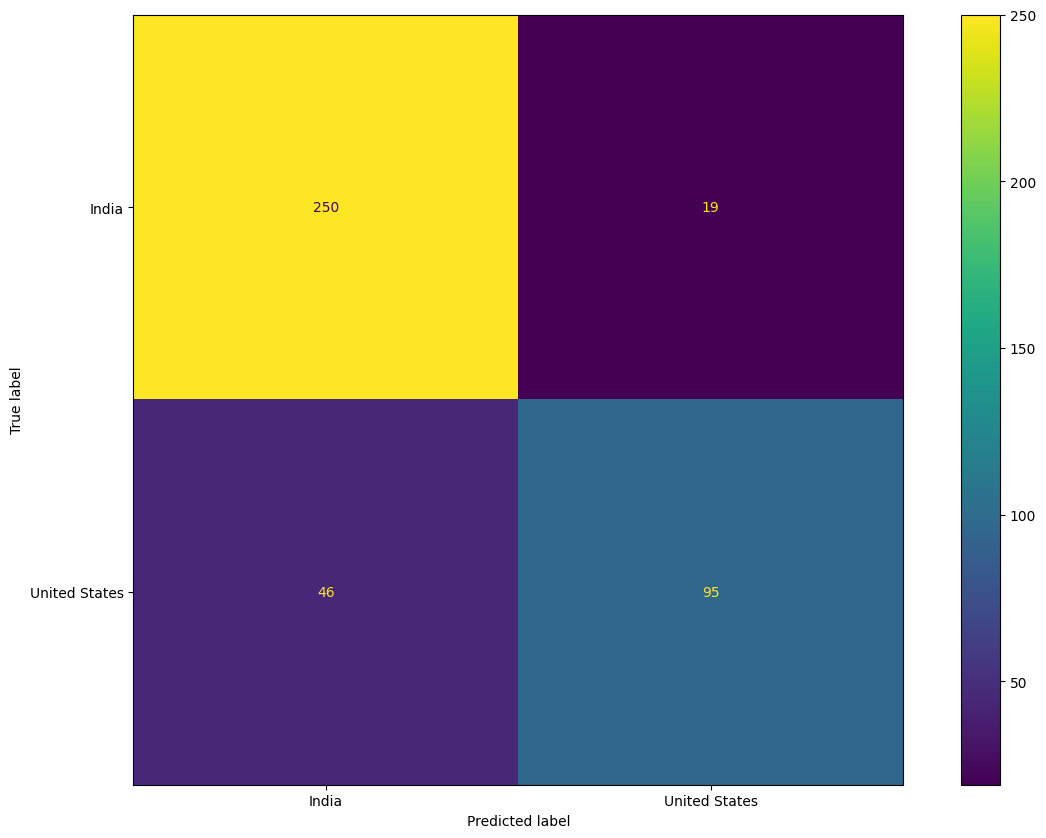

In [ ]:
print(classification_report(y_true, y_codebert_test_pred, target_names=enc.classes_.tolist()))

print("f1_score_macro : ",f1_score(y_true, y_codebert_test_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_test_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_test_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_train_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_train_pred += predictions.tolist()

               precision    recall  f1-score   support

        India       0.97      0.98      0.97       940
United States       0.96      0.94      0.95       493

     accuracy                           0.96      1433
    macro avg       0.96      0.96      0.96      1433
 weighted avg       0.96      0.96      0.96      1433

f1_score_macro :  0.960400487008501
f1_score_weighted :  0.9643311863850661


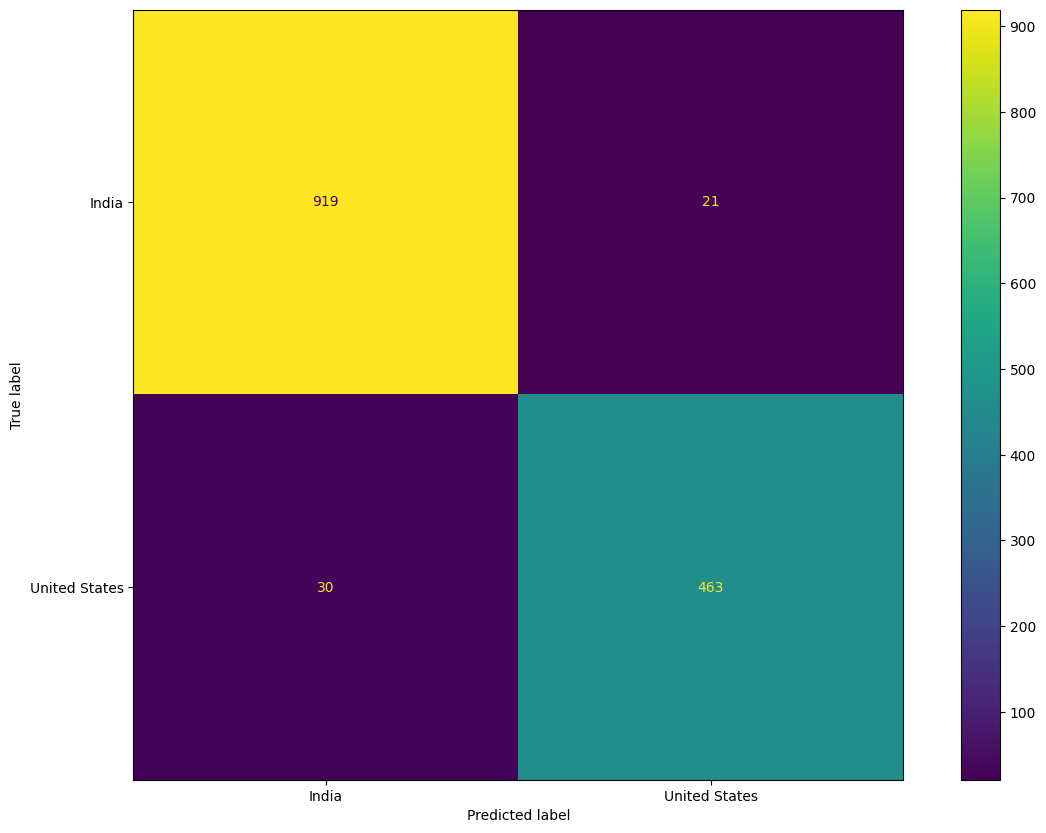

In [ ]:
print(classification_report(y_true, y_codebert_train_pred, target_names=enc.classes_.tolist()))

print("f1_score_macro : ",f1_score(y_true, y_codebert_train_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_train_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_train_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# Error Analysis

In [ ]:
test_df = leetcode_questions_df.loc[X_test_text.index]

In [ ]:
test_df['correct'] = y_codebert_test_pred == y_test

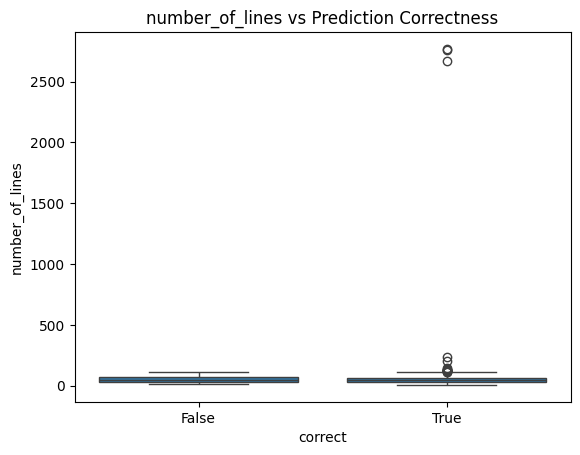

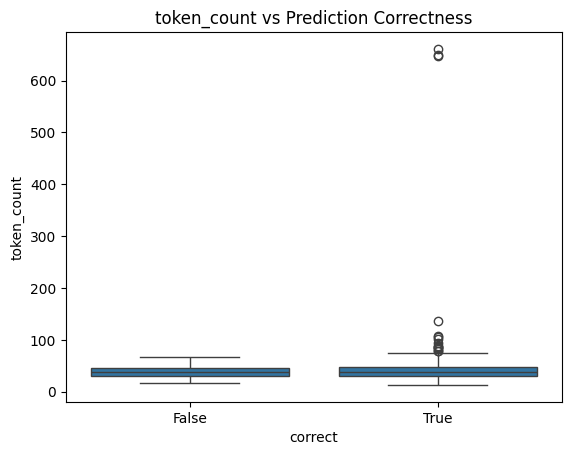

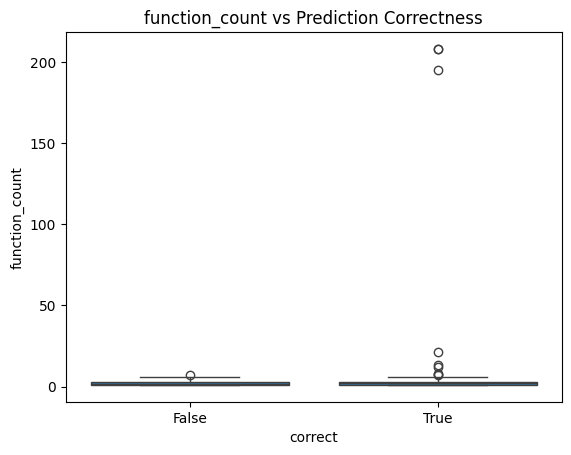

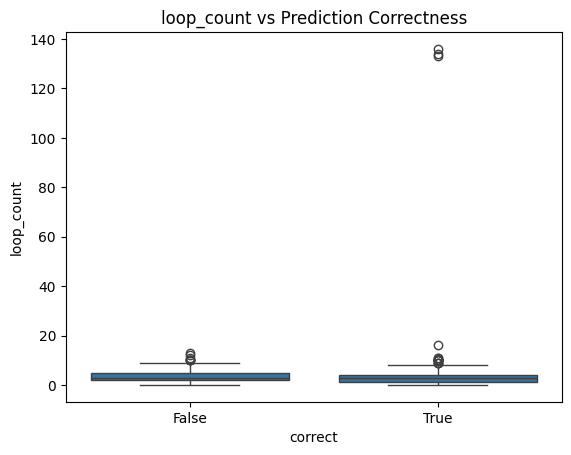

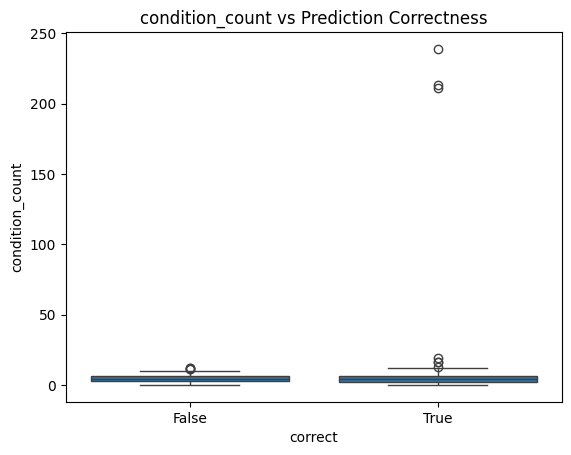

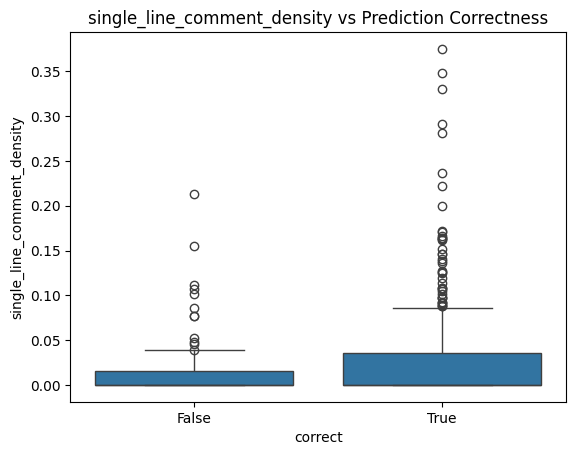

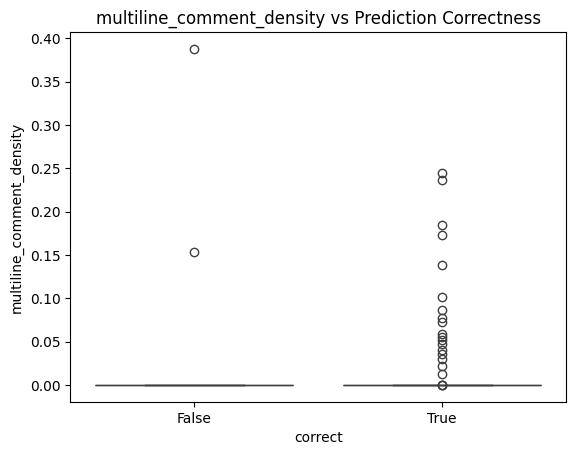

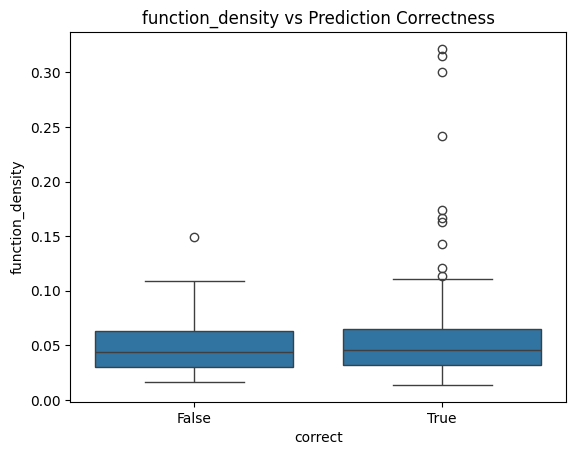

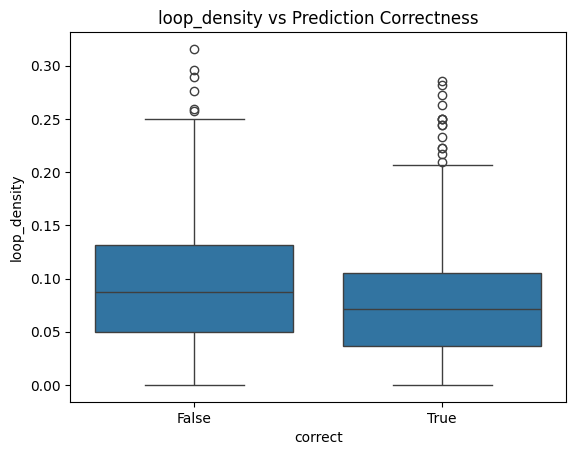

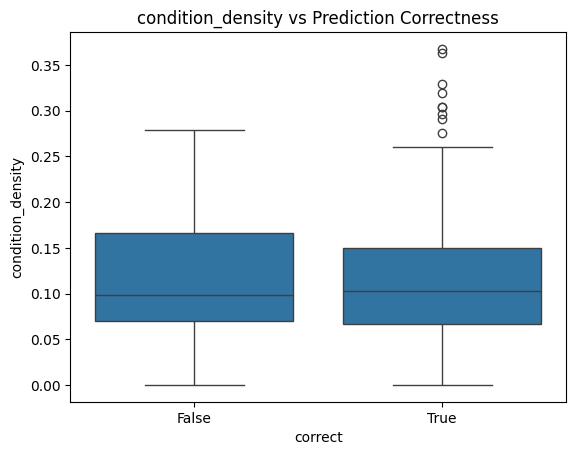

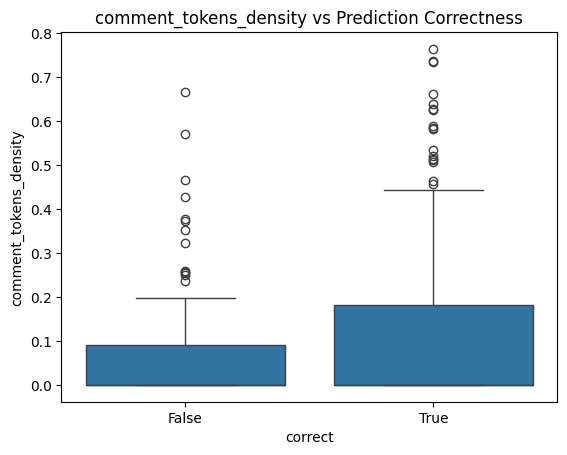

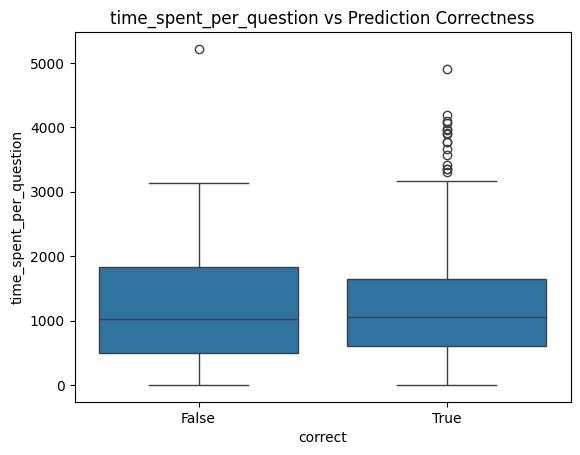

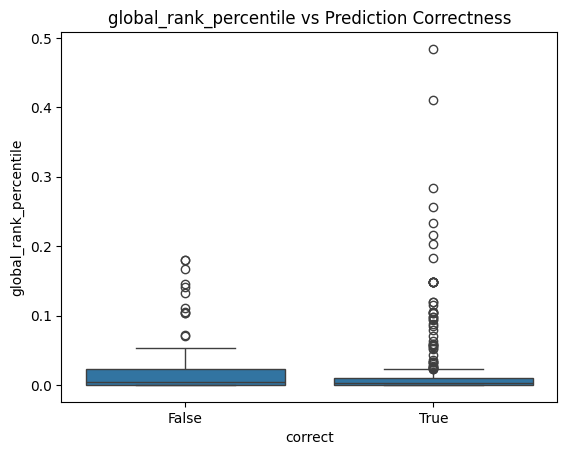

In [ ]:
features_to_plot = [
    'number_of_lines', 'token_count', 'function_count',
    'loop_count', 'condition_count',
    'single_line_comment_density', 'multiline_comment_density',
    'function_density', 'loop_density', 'condition_density',
    'comment_tokens_density', 'time_spent_per_question',
    'global_rank_percentile'
]

for col in features_to_plot:
    sns.boxplot(x='correct', y=col, data=test_df)
    plt.title(f'{col} vs Prediction Correctness')
    plt.show()

In [ ]:
test_df.groupby('correct')[features_to_plot].mean().T.sort_values(by=False, ascending=False)

correct,False,True
time_spent_per_question,1197.042553,1243.702532
number_of_lines,52.085106,75.186709
token_count,38.808511,46.319620
condition_count,4.521277,6.474684
loop_count,3.968085,4.439873
function_count,1.968085,4.000000
condition_density,0.116638,0.111255
loop_density,0.103591,0.080332
comment_tokens_density,0.070662,0.101723
function_density,0.050073,0.053142


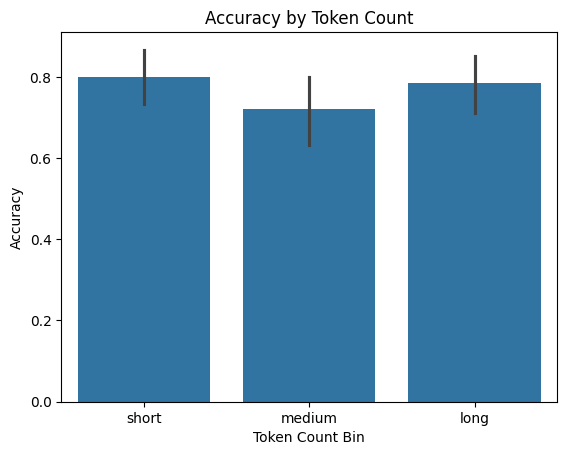

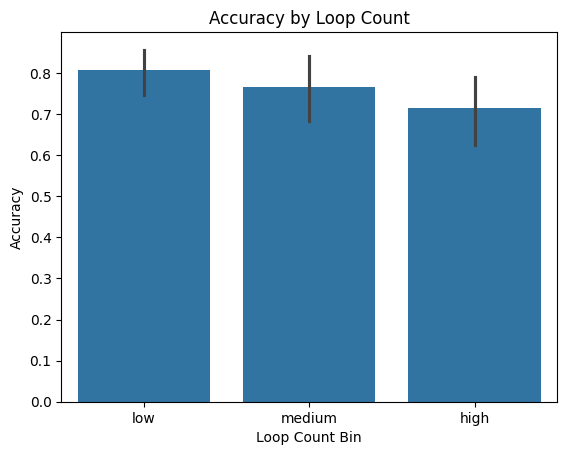

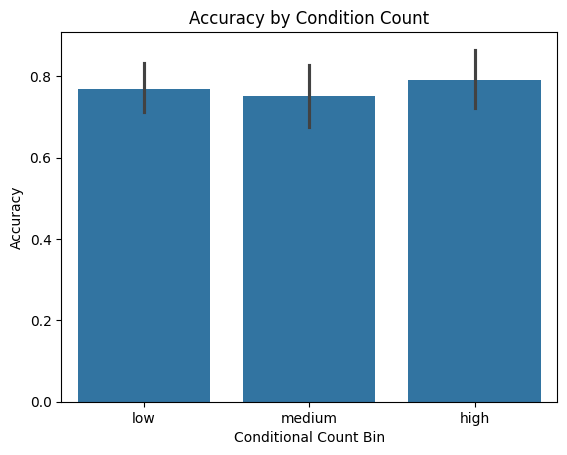

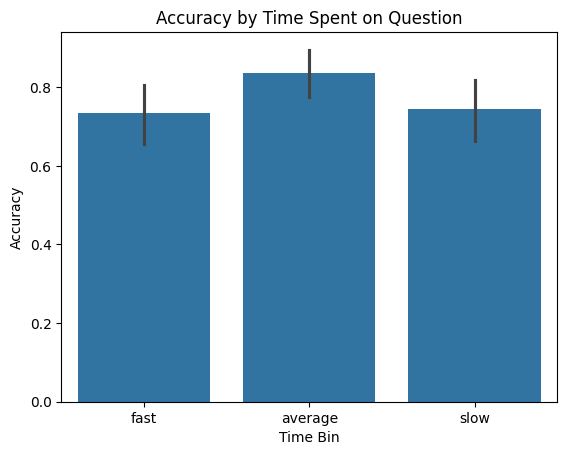

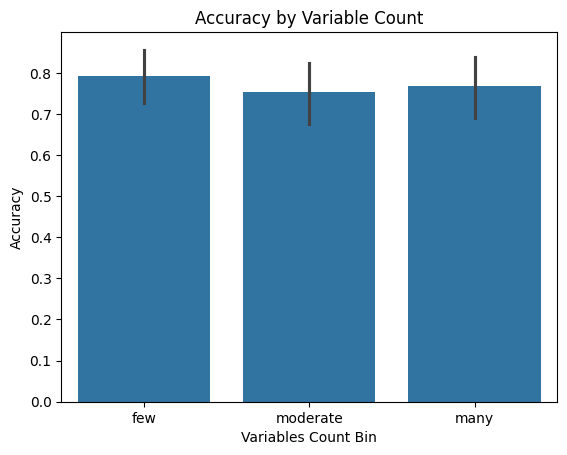

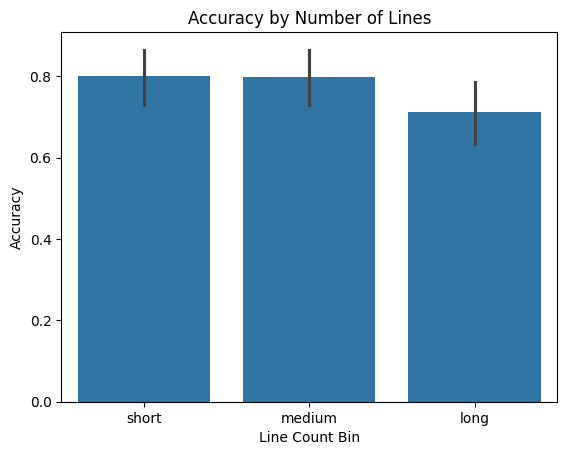

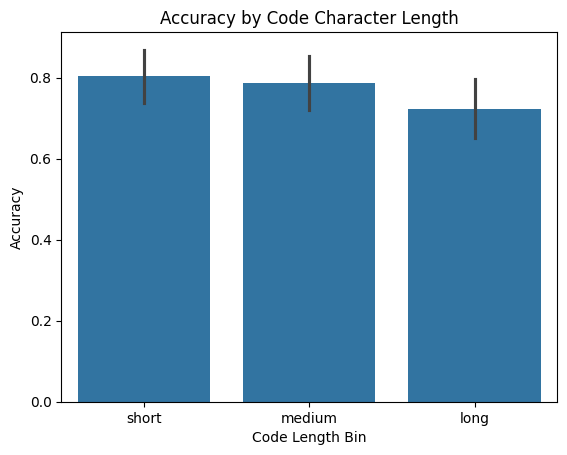

In [ ]:
import seaborn as sns

# --------------------------
# Binning Continuous Features
# --------------------------
test_df['token_bin'] = pd.qcut(test_df['token_count'], 3, labels=["short", "medium", "long"])
test_df['line_bin'] = pd.qcut(test_df['number_of_lines'], 3, labels=["short", "medium", "long"])
test_df['loop_bin'] = pd.qcut(test_df['loop_count'], 3, labels=["low", "medium", "high"])
test_df['cond_bin'] = pd.qcut(test_df['condition_count'], 3, labels=["low", "medium", "high"])
test_df['time_bin'] = pd.qcut(test_df['time_spent_per_question'], 3, labels=["fast", "average", "slow"])
test_df['var_bin'] = pd.qcut(test_df['variables_count'], 3, labels=["few", "moderate", "many"])
test_df['code_len_bin'] = pd.qcut(test_df['question_code_length'], 3, labels=["short", "medium", "long"])

# --------------------------
# 1. Barplot: Accuracy by Token Count Bin
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='token_bin', y='correct')
plt.title("Accuracy by Token Count")
plt.xlabel("Token Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 2. Barplot: Accuracy by Loop Count Bin
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='loop_bin', y='correct')
plt.title("Accuracy by Loop Count")
plt.xlabel("Loop Count Bin")
plt.ylabel("Accuracy")
plt.show()


# --------------------------
# 3. Barplot: Conditional Count
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='cond_bin', y='correct')
plt.title("Accuracy by Condition Count")
plt.xlabel("Conditional Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 4. Barplot: Time Spent per Question
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='time_bin', y='correct')
plt.title("Accuracy by Time Spent on Question")
plt.xlabel("Time Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 5. Barplot: Variable Count
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='var_bin', y='correct')
plt.title("Accuracy by Variable Count")
plt.xlabel("Variables Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 6. Barplot: Number of Lines
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='line_bin', y='correct')
plt.title("Accuracy by Number of Lines")
plt.xlabel("Line Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 7. Barplot: Code Character Length
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='code_len_bin', y='correct')
plt.title("Accuracy by Code Character Length")
plt.xlabel("Code Length Bin")
plt.ylabel("Accuracy")
plt.show()
